In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 19.8 MB/s eta 0:00:00


In [ ]:
import scipy
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
from statsmodels.stats.multitest import fdrcorrection
import mne
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
mat_data = scipy.io.loadmat('/content/drive/MyDrive/approximate_entropy.mat')
approx = mat_data['approx']

df = pd.DataFrame(approx)

def remove_brackets(x):
    if isinstance(x, np.ndarray) and x.size == 1:
        return x.item()  # Convert single-element array to scalar
    return x

# Apply the function to all elements in the DataFrame
df = df.map(remove_brackets)

df.columns = df.iloc[0].str.replace('.set', '', regex=False)

# Remove the first row (now redundant)
df = df.iloc[1:].reset_index(drop=True)

df.to_csv('apen.csv', index=False)

In [ ]:
# Function to categorize column names
def categorize_column(col_name):
    condition = 'ctrl' if 'ctrl' in col_name else 'psi'
    activity = next((act for act in ['meditation', 'video', 'restingstate', 'music'] if act in col_name), 'unknown')
    return condition, activity

# Dictionary to store our new DataFrames
new_dfs = {}

# Split data into separate DataFrames
for condition in ['ctrl', 'psi']:
    for activity in ['meditation', 'video', 'restingstate', 'music']:
        # Select columns matching the current combination
        selected_columns = [col for col in df.columns if all(cat in col for cat in [condition, activity])]

        if selected_columns:
            # Create a new DataFrame with selected columns
            var_name = f"{condition}_{activity}"
            new_dfs[var_name] = df[selected_columns]
            print(f"Created DataFrame: {var_name} with {len(selected_columns)} columns")

Created DataFrame: ctrl_meditation with 60 columns
Created DataFrame: ctrl_video with 53 columns
Created DataFrame: ctrl_restingstate with 59 columns
Created DataFrame: ctrl_music with 60 columns
Created DataFrame: psi_meditation with 54 columns
Created DataFrame: psi_video with 39 columns
Created DataFrame: psi_restingstate with 52 columns
Created DataFrame: psi_music with 52 columns


In [ ]:
# Split df to control and psi
df_ctrl = df.iloc[:, 1:233]
df_psi = df.iloc[:, 233:]

def perform_comparison(df1, df2, electrodes):
    all_pval = []
    for electrode in electrodes:
        stats, pval = scipy.stats.ttest_ind(
            a=df1.loc[electrode].astype(float),
            b=df2.loc[electrode].astype(float),
            nan_policy='omit'
        )
        all_pval.append(pval)

    all_pval = pd.Series(all_pval, index=electrodes, name='p_value')
    _, fdr_results = fdrcorrection(all_pval)

    return pd.Series(fdr_results, index=electrodes, name='FDR')

# Extract electrode labels
electrodes = df['Approximate Entropy'].tolist()

# Create DataFrames for subcategories
subcategories = {}
for condition in ['ctrl', 'psi']:
    for activity in ['meditation', 'video', 'restingstate', 'music']:
        selected_columns = [col for col in df.columns if all(cat in col for cat in [condition, activity])]
        if selected_columns:
            var_name = f"{condition}_{activity}"
            subcategories[var_name] = df[selected_columns]

# Ensure all subcategories have the same index (electrodes)
for subcat in subcategories.values():
    subcat.index = electrodes

# Also ensure df_ctrl and df_psi have the correct index
df_ctrl.index = electrodes
df_psi.index = electrodes

# Perform comparisons and store results
comparisons = [
    ("Overall", df_ctrl, df_psi),
    ("Meditation", subcategories['ctrl_meditation'], subcategories['psi_meditation']),
    ("Video", subcategories['ctrl_video'], subcategories['psi_video']),
    ("Resting State", subcategories['ctrl_restingstate'], subcategories['psi_restingstate']),
    ("Music", subcategories['ctrl_music'], subcategories['psi_music'])
]

# Create the result matrix
result_matrix = pd.DataFrame(index=electrodes)
result_matrix['Electrodes'] = electrodes  # Use 'Approximate Entropy' as labels

for name, df1, df2 in comparisons:
    result_matrix[name] = perform_comparison(df1, df2, electrodes)

# Convert all columns except 'Electrodes' to float
for column in result_matrix.columns:
    if column != 'Electrodes':
        result_matrix[column] = pd.to_numeric(result_matrix[column], errors='coerce')

# Reorder columns to have 'Electrodes' as the first column
cols = ['Electrodes'] + [col for col in result_matrix.columns if col != 'Electrodes']
result_matrix = result_matrix[cols]

# Save the matrix to a CSV file
result_matrix.to_csv('fdr_comparison_matrix_preserved_order.csv', index=False)

# print(result_matrix.iloc[0:60,:].sort_values(by='Overall', ascending=True))


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats
from statsmodels.stats.multitest import fdrcorrection

def reorganize_data(df):
    """
    Reorganize data by splitting ctrl and psi conditions while ensuring matched pairs
    """
    # Get all ctrl and psi columns
    ctrl_cols = [col for col in df.columns if col.startswith('ctrl_sub')]
    psi_cols = [col for col in df.columns if col.startswith('psi_sub')]

    # Extract subject numbers and activities
    def get_subject_activity(col):
        parts = col.split('_')
        return (parts[1], parts[2])  # (sub001, meditation)

    # Get unique (subject, activity) pairs that exist in both conditions
    ctrl_pairs = {get_subject_activity(col) for col in ctrl_cols}
    psi_pairs = {get_subject_activity(col) for col in psi_cols}
    common_pairs = ctrl_pairs.intersection(psi_pairs)

    # Filter columns for only common (subject, activity) pairs
    matched_ctrl_cols = [col for col in ctrl_cols if get_subject_activity(col) in common_pairs]
    matched_psi_cols = [col for col in psi_cols if get_subject_activity(col) in common_pairs]

    # Sort columns to ensure matching order
    matched_ctrl_cols.sort()
    matched_psi_cols.sort()

    # Create new dataframes with only matched pairs
    df_ctrl = df[matched_ctrl_cols].copy()
    df_psi = df[matched_psi_cols].copy()

    print(f"Found {len(common_pairs)} matched subject-activity pairs")
    print(f"Control shape: {df_ctrl.shape}, PSI shape: {df_psi.shape}")

    return df_ctrl, df_psi

def get_activity_data(df, activity):
    """
    Extract columns for a specific activity
    """
    return df.loc[:, [col for col in df.columns if activity in col]]

def perform_paired_comparison(df_ctrl, df_psi, electrodes):
    """
    Perform paired t-test between control and psi conditions
    """
    all_pval = []

    for electrode in electrodes:
        # Get paired samples for this electrode
        ctrl_data = df_ctrl.loc[electrode].astype(float)
        psi_data = df_psi.loc[electrode].astype(float)

        # Perform paired t-test (nan_policy='omit' will handle NaN values)
        stats, pval = scipy.stats.ttest_rel(
            a=ctrl_data,
            b=psi_data,
            nan_policy='omit'
        )
        all_pval.append(pval)

    all_pval = pd.Series(all_pval, index=electrodes, name='p_value')
    # Perform FDR correction
    _, fdr_results = fdrcorrection(all_pval)

    return pd.Series(fdr_results, index=electrodes, name='FDR')

# Extract electrode labels
electrodes = df['Approximate Entropy'].tolist()

# Split data into control and psi conditions with matched pairs
df_ctrl, df_psi = reorganize_data(df)

# Set the index for both dataframes
df_ctrl.index = electrodes
df_psi.index = electrodes

# Initialize result matrix
result_matrix = pd.DataFrame(index=electrodes)
result_matrix['Electrodes'] = electrodes

# Perform overall comparison
result_matrix['Overall'] = perform_paired_comparison(df_ctrl, df_psi, electrodes)

# Perform comparisons for each activity
activities = ['meditation', 'video', 'restingstate', 'music']
for activity in activities:
    ctrl_activity = get_activity_data(df_ctrl, activity)
    psi_activity = get_activity_data(df_psi, activity)

    if not ctrl_activity.empty and not psi_activity.empty:
        result_matrix[activity.capitalize()] = perform_paired_comparison(
            ctrl_activity, psi_activity, electrodes
        )

# Convert numeric columns to float
numeric_cols = [col for col in result_matrix.columns if col != 'Electrodes']
result_matrix[numeric_cols] = result_matrix[numeric_cols].astype(float)

# After generating the result matrix but before saving to CSV, add:
result_matrix = result_matrix.rename(columns={'Restingstate': 'Resting State'})

# Then continue with saving
result_matrix.to_csv('fdr_comparison_matrix_paired_tests.csv', index=False)

# Optional: Print first few rows sorted by Overall p-value
print("\nFirst 60 results sorted by Overall p-value:")
print(result_matrix.iloc[0:60,:].sort_values(by='Overall', ascending=True))

Found 182 matched subject-activity pairs
Control shape: (64, 182), PSI shape: (64, 182)

First 60 results sorted by Overall p-value:
     Electrodes       Overall  Meditation     Video  Resting State     Music
FC1         FC1  2.753527e-14    0.000171  0.594741       0.000022  0.000198
P6           P6  4.176114e-13    0.001342  0.594741       0.000059  0.000198
FC2         FC2  5.798354e-13    0.000171  0.662447       0.000079  0.000212
P7           P7  5.798354e-13    0.000171  0.632634       0.000079  0.000198
FC4         FC4  5.798354e-13    0.000003  0.878687       0.000079  0.000532
FC3         FC3  1.595840e-12    0.000184  0.671874       0.000135  0.000198
P5           P5  5.887407e-12    0.000608  0.671874       0.000079  0.000212
P8           P8  2.997048e-11    0.002300  0.662447       0.000079  0.000212
C1           C1  6.494136e-11    0.000194  0.955279       0.000133  0.000224
F1           F1  6.647425e-11    0.002246  0.594741       0.000115  0.000810
PO7         PO7  8.2

Opening raw data file /content/drive/MyDrive/eeg_template.fif...
    Range : 0 ... 0 =      0.000 ...     0.000 secs
Ready.
Reading 0 ... 0  =      0.000 ...     0.000 secs...


<ipython-input-11-102648afe758>:25: RuntimeWarning: This filename (/content/drive/MyDrive/eeg_template.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  eeg_template = mne.io.read_raw_fif('/content/drive/MyDrive/eeg_template.fif', preload=True)


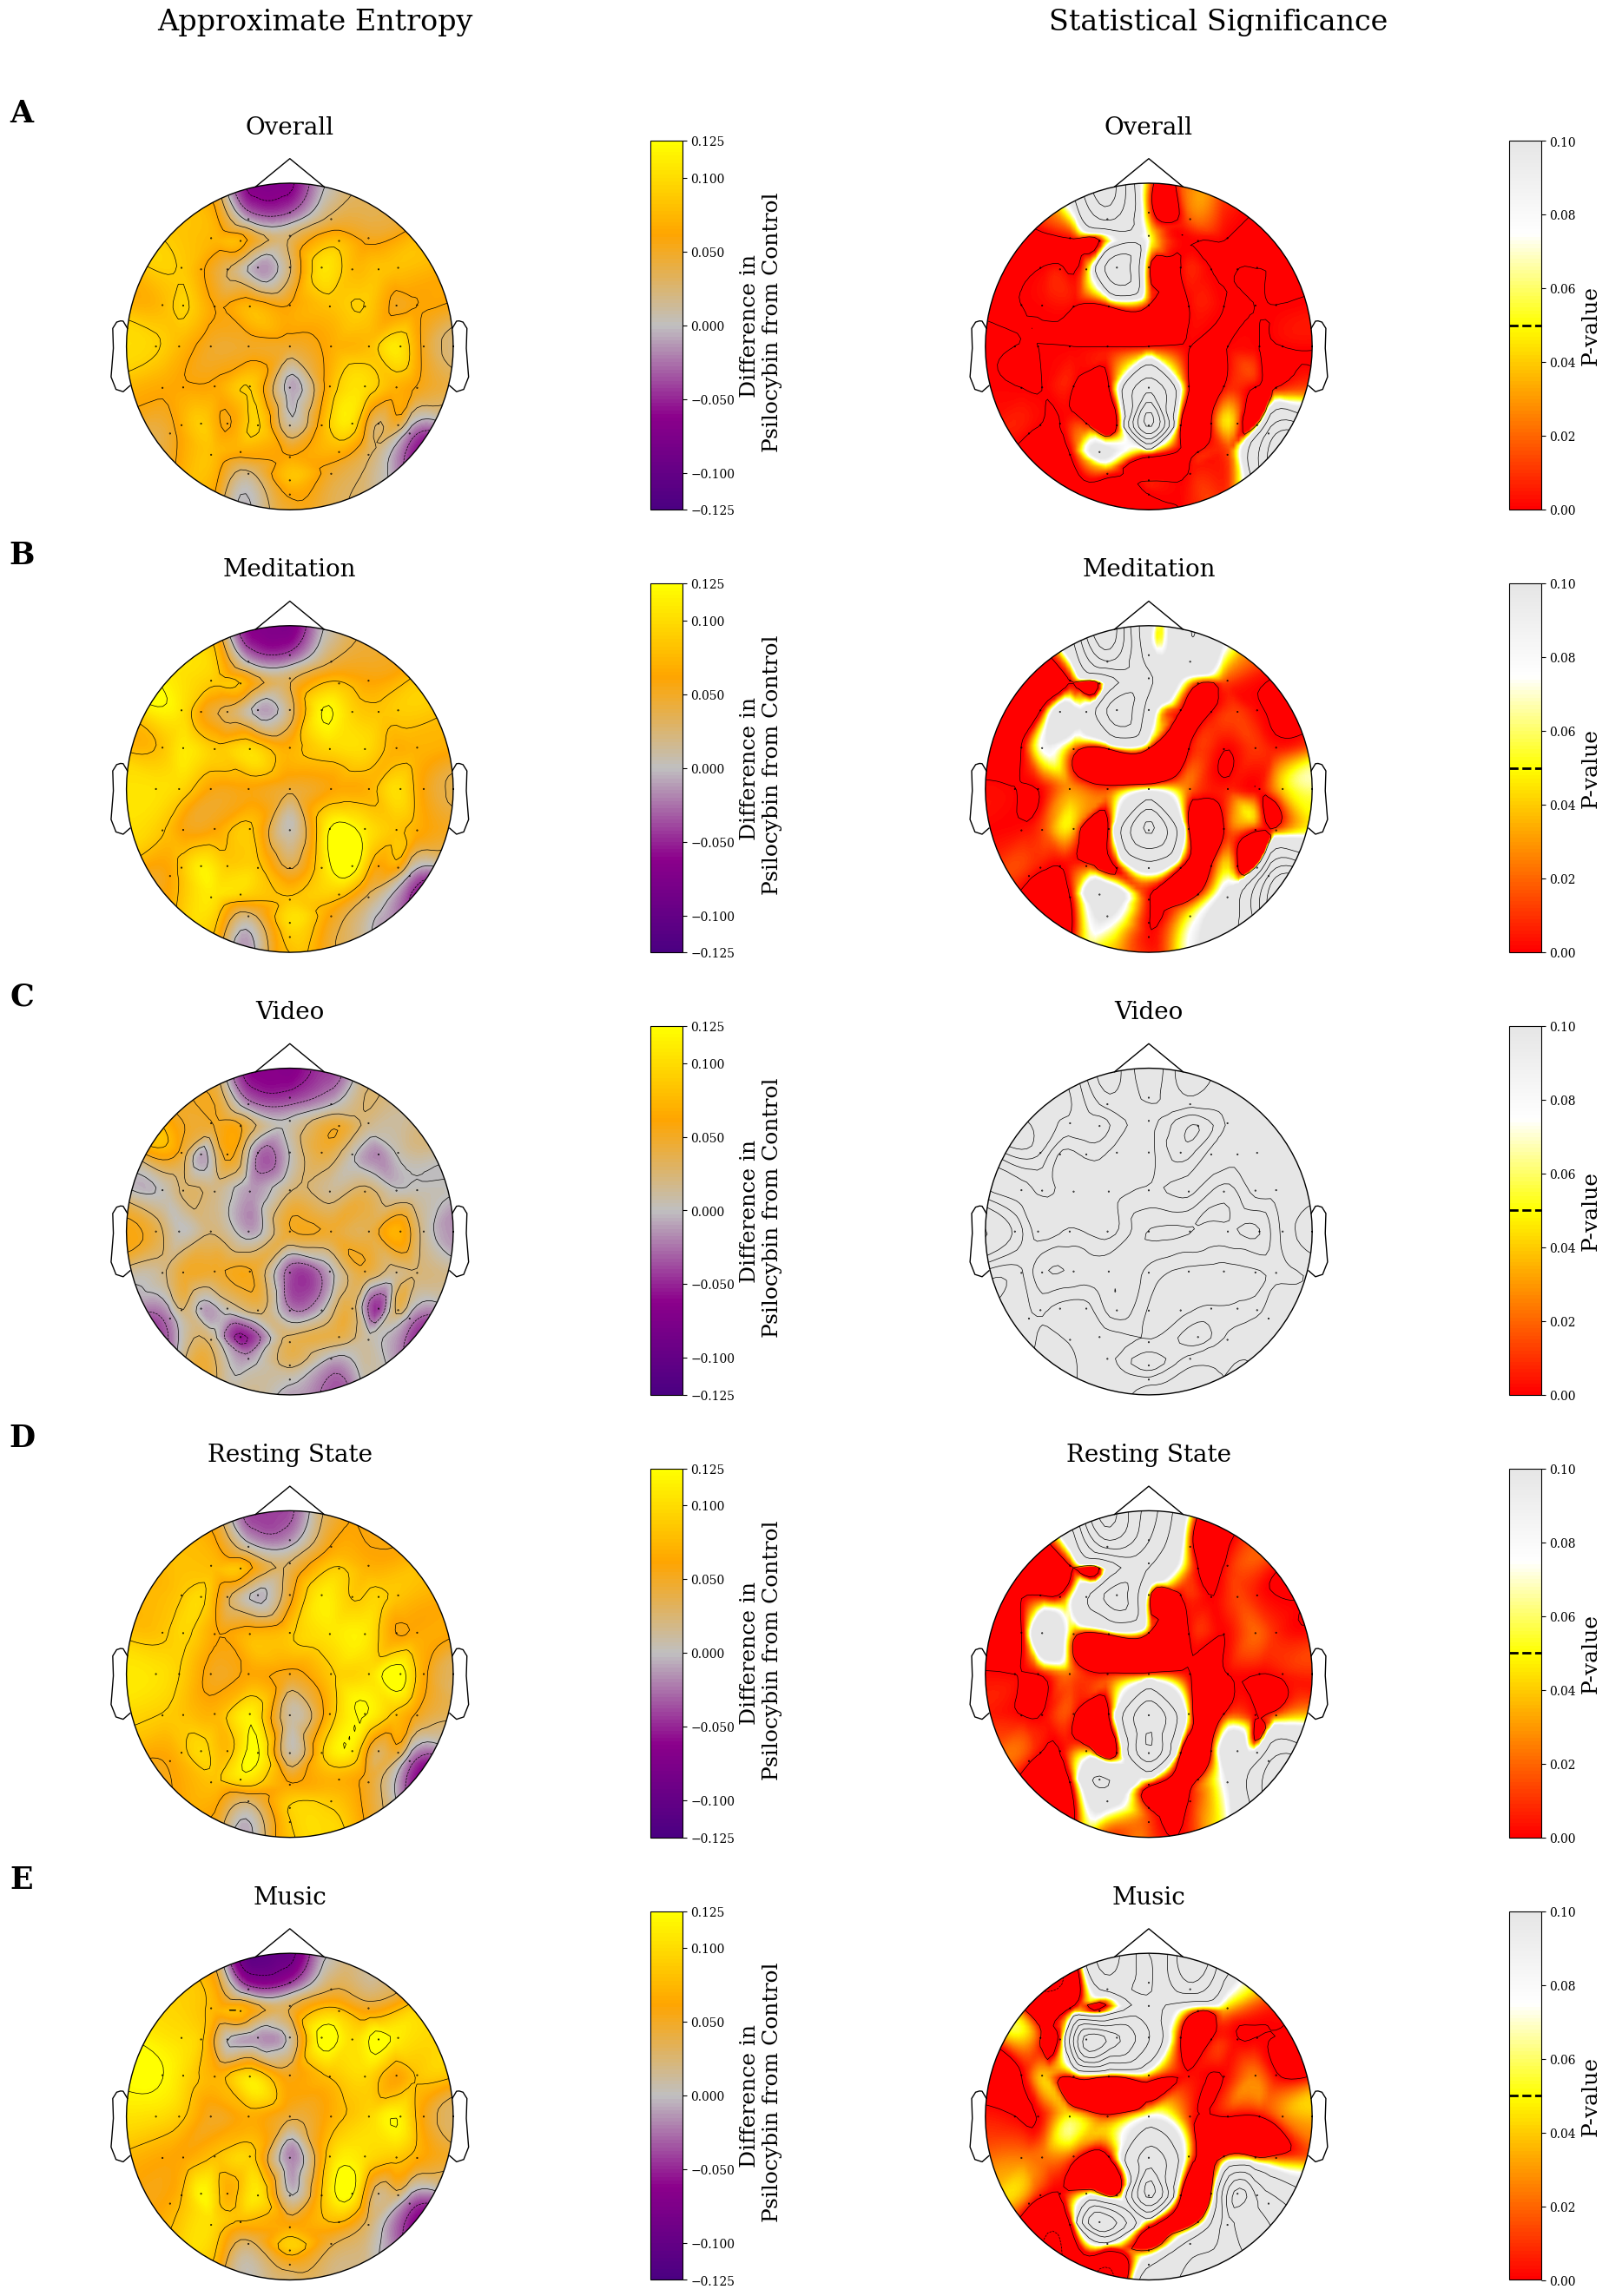

EEG channels: 64
ctrl_meditation shape: (64, 60)
ctrl_video shape: (64, 53)
ctrl_restingstate shape: (64, 59)
ctrl_music shape: (64, 60)
psi_meditation shape: (64, 54)
psi_video shape: (64, 39)
psi_restingstate shape: (64, 52)
psi_music shape: (64, 52)
P-value DataFrame shape: (64, 5)
ApEn range: -0.125 to 0.125
P-value range: 2.7535268278011126e-14 to 0.1


In [ ]:
# Helper functions
def prepare_data(data):
    return data[:len(info.ch_names)]

def calculate_difference(psi_df, ctrl_df):
    return psi_df.mean(axis=1) - ctrl_df.mean(axis=1)

def prepare_pvalue_data(result_matrix):
    df = pd.DataFrame(result_matrix, columns=['Electrodes', 'Overall', 'Meditation', 'Video', 'Resting State', 'Music'])
    df.set_index('Electrodes', inplace=True)
    return df.astype(float)

def plot_topomap(data, info, ax, title, vmin, vmax, cmap):
    im, _ = mne.viz.plot_topomap(data, info, axes=ax, show=False,
                                 cmap=cmap, sensors=True, contours=6,
                                 vlim=(vmin, vmax))
    ax.set_title(title, fontsize=20)
    return im

# Set the font to Roman (Times New Roman)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

# Load EEG template and set up montage
eeg_template = mne.io.read_raw_fif('/content/drive/MyDrive/eeg_template.fif', preload=True)
montage = mne.channels.make_standard_montage('biosemi64')
info = mne.create_info(ch_names=montage.ch_names[:64], sfreq=eeg_template.info['sfreq'], ch_types='eeg')
info.set_montage(montage)

# Prepare data
pvalue_df = prepare_pvalue_data(result_matrix)

apen_cmap = LinearSegmentedColormap.from_list("custom_apen", ['#4B0082', '#8B008B', '#C0C0C0', '#FFA500', '#FFFF00'], N=100)

pvalue_cmap = LinearSegmentedColormap.from_list("custom_pvalue",
    ['#FF0000', '#FF8000', '#FFFF00', '#FFFFFF', '#E6E6E6'], N=100)

# Set up plot
fig = plt.figure(figsize=(26, 32))
gs = fig.add_gridspec(5, 7, width_ratios=[0.5, 10, 0.5, 1, 10, 0.5, 1], height_ratios=[1, 1, 1, 1, 1])

# Helper functions (keep all your existing helper functions)

# Setup (keep all your existing setup code until the activities definition)

activities = ['Overall', 'Meditation', 'Video', 'Resting State', 'Music']

# Remove the problematic all_diffs calculation and directly start with plotting
apen_vmin, apen_vmax = -0.125, 0.125
pvalue_vmin, pvalue_vmax = pvalue_df.min().min(), 0.1

diff_means = calculate_difference(df_psi, df_ctrl)

# Add column titles
fig.text(0.31, 0.92, 'Approximate Entropy', fontsize=24, ha='center')
fig.text(0.71, 0.92, 'Statistical Significance', fontsize=24, ha='center')

# Plot topomaps
for i, activity in enumerate(activities):
    # Add row label
    fig.text(0.18, 0.89 - i*0.159, chr(65+i), fontsize=25, ha='center', va='center', weight='bold')

    # Prepare ApEn data
    if activity == 'Overall':
        apen_data = prepare_data(diff_means.to_numpy().reshape(-1))
    else:
        activity_name = activity.lower().replace(" ", "")
        psi_cols = [col for col in df_psi.columns if activity_name in col.lower()]
        ctrl_cols = [col for col in df_ctrl.columns if activity_name in col.lower()]
        apen_data = prepare_data(calculate_difference(
            df_psi[psi_cols],
            df_ctrl[ctrl_cols]
        ).to_numpy().reshape(-1))

    # Plot ApEn
    ax_apen = fig.add_subplot(gs[i, 1])
    im_apen = plot_topomap(apen_data, info, ax_apen, f'{activity}', apen_vmin, apen_vmax, apen_cmap)
    cbar_apen = fig.colorbar(im_apen, cax=fig.add_subplot(gs[i, 2]), aspect=10)
    cbar_apen.set_label('Difference in\n Psilocybin from Control', fontsize=18)

    # Plot p-values
    ax_pvalue = fig.add_subplot(gs[i, 4])
    im_pvalue = plot_topomap(pvalue_df[activity].values, info, ax_pvalue, f'{activity}',
                             pvalue_vmin, pvalue_vmax, pvalue_cmap)
    cbar_pvalue = fig.colorbar(im_pvalue, cax=fig.add_subplot(gs[i, 5]), aspect=10)
    cbar_pvalue.set_label('P-value', fontsize=18)

    # Add a line to mark the significance threshold
    cbar_pvalue.ax.axhline(y=0.05, color='k', linestyle='--', linewidth=2)

plt.savefig('eeg_topomap_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Debug info
print(f"EEG channels: {len(eeg_template.ch_names)}")
for key, df in new_dfs.items():
    print(f"{key} shape: {df.shape}")
print(f"P-value DataFrame shape: {pvalue_df.shape}")
print(f"ApEn range: {apen_vmin} to {apen_vmax}")
print(f"P-value range: {pvalue_vmin} to {pvalue_vmax}")